# Data Cleaning

In [ ]:
import pandas as pd
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [ ]:
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

## Text Cleaning Exercise

In [ ]:
df = pd.read_csv('sample_dirty_text.csv')

In [ ]:
print(df['noisy_text'].head())

0          This JOB is AMAZING!!!
1           Worst. Manager. EVER.
2    pay is good, but hours? meh.
3       THE benefits are... okay.
4      I just don't know anymore.
Name: noisy_text, dtype: object


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   noisy_text  10 non-null     object
dtypes: object(1)
memory usage: 212.0+ bytes
None


In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # make lowercase
    text = text.lower()

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # tokenize and remove stopwords
    tokens = word_tokenize(text)
    cleaned_tokens = [word for word in tokens if word not in stop_words]

    # join back into a single string
    return " ".join(cleaned_tokens)

In [ ]:
nltk.download('punkt_tab')
df['cleaned_text'] = df['noisy_text'].apply(clean_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
print(df[['noisy_text', 'cleaned_text']].head())

                     noisy_text        cleaned_text
0        This JOB is AMAZING!!!         job amazing
1         Worst. Manager. EVER.  worst manager ever
2  pay is good, but hours? meh.  pay good hours meh
3     THE benefits are... okay.       benefits okay
4    I just don't know anymore.   dont know anymore


In [ ]:
df.to_csv('sample_cleaned_text.csv', index=False)

## Glassdoor Data

In [ ]:
glass = pd.read_csv("glassdoor_cleaned_v2.csv")

In [ ]:
print(glass.head())

   review_id               rating_date  count_helpful  count_unhelpful  \
0          1  2025-06-03T00:00:00.000Z              0                0   
1          2  2025-05-29T00:00:00.000Z              0                0   
2          7  2025-05-17T00:00:00.000Z              0                0   
3          8  2025-05-15T00:00:00.000Z              0                0   
4          9  2025-05-14T00:00:00.000Z              0                0   

   employee_length employee_status                       employee_type  \
0                0         REGULAR                    Current employee   
1                1        CONTRACT  Current employee, less than 1 year   
2                4         REGULAR                   Current employees   
3                0         REGULAR                    Current employee   
4                1         REGULAR   Former employee, less than 1 year   

  flags_business_outlook flags_ceo_approval flags_recommend_frend  ...  \
0                    NaN            

In [ ]:
nltk.download('punkt_tab')
glass['cleaned_summary'] = glass['summary'].apply(clean_text)
glass['cleaned_advice'] = glass['advice_to_management'].apply(clean_text)
glass['cleaned_pros'] = glass['review_pros'].apply(clean_text)
glass['cleaned_cons'] = glass['review_cons'].apply(clean_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
print(glass.head())

   review_id               rating_date  count_helpful  count_unhelpful  \
0          1  2025-06-03T00:00:00.000Z              0                0   
1          2  2025-05-29T00:00:00.000Z              0                0   
2          7  2025-05-17T00:00:00.000Z              0                0   
3          8  2025-05-15T00:00:00.000Z              0                0   
4          9  2025-05-14T00:00:00.000Z              0                0   

   employee_length employee_status                       employee_type  \
0                0         REGULAR                    Current employee   
1                1        CONTRACT  Current employee, less than 1 year   
2                4         REGULAR                   Current employees   
3                0         REGULAR                    Current employee   
4                1         REGULAR   Former employee, less than 1 year   

  flags_business_outlook flags_ceo_approval flags_recommend_frend  ...  \
0                    NaN            

In [ ]:
glass.to_csv("glassdoor_cleaned_text.csv", index=False)

## Youtube Data

In [ ]:
def clean_transcript(text):
    if not isinstance(text, str):
        return ""

    # Remove timestamps (e.g., 0:08, 12:35, 1:02:44)
    text = re.sub(r'\b\d{1,2}:\d{2}(?::\d{2})?\b', '', text)

    # Remove extra line breaks
    text = text.replace('\n', ' ')

    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    cleaned_tokens = [word for word in tokens if word not in stop_words]

    return " ".join(cleaned_tokens)

In [ ]:
youtube = pd.read_csv("Youtube_Review_Template.csv")
print(youtube.head())

   Video_Number                                         Link Upload_Date  \
0             1  https://www.youtube.com/watch?v=tgWkQC3_b30    May 2020   
1             2  https://www.youtube.com/watch?v=_kVao-XyKgQ    Jun 2020   
2             3  https://www.youtube.com/watch?v=3ytZ8_6ieoI   June 2021   
3             4  https://www.youtube.com/watch?v=jzg4snTtk3E    Aug 2022   
4             5  https://www.youtube.com/watch?v=kXOb9lfWU9w    Dec 2023   

     Views  Likes  Comments                                         Transcript  
0  1653124  23000      7974  0:08\nwhat is up guys I'm back with another\n0...  
1   525522  24000      2395  Intro\n0:00\nwhat is up guys I'm back with yet...  
2   114049   2300       543  0:00\nso today's video is going to be a little...  
3   227920   3500       753  0:00\n[Music]\n0:07\nso it's 7 23\n0:09\nmy sh...  
4     7346    298        41  0:00\n[Music]\n0:06\nI hey you guys what's up ...  


In [ ]:
import re
youtube['transcript_cleaned'] = youtube['Transcript'].apply(clean_transcript)
print(youtube.head())

   Video_Number                                         Link Upload_Date  \
0             1  https://www.youtube.com/watch?v=tgWkQC3_b30    May 2020   
1             2  https://www.youtube.com/watch?v=_kVao-XyKgQ    Jun 2020   
2             3  https://www.youtube.com/watch?v=3ytZ8_6ieoI   June 2021   
3             4  https://www.youtube.com/watch?v=jzg4snTtk3E    Aug 2022   
4             5  https://www.youtube.com/watch?v=kXOb9lfWU9w    Dec 2023   

     Views  Likes  Comments  \
0  1653124  23000      7974   
1   525522  24000      2395   
2   114049   2300       543   
3   227920   3500       753   
4     7346    298        41   

                                          Transcript  \
0  0:08\nwhat is up guys I'm back with another\n0...   
1  Intro\n0:00\nwhat is up guys I'm back with yet...   
2  0:00\nso today's video is going to be a little...   
3  0:00\n[Music]\n0:07\nso it's 7 23\n0:09\nmy sh...   
4  0:00\n[Music]\n0:06\nI hey you guys what's up ...   

                   

In [ ]:
youtube.to_csv("youtube_cleaned_text.csv", index=False)

## Visualizations and EDA

### Glassdoor

In [ ]:
from collections import Counter

# Join all cleaned pros into one big string, then split into words
all_pros_words = ' '.join(glass['cleaned_pros']).split()

# Count frequency of each word
pros_word_counts = Counter(all_pros_words)

In [ ]:
print(pros_word_counts.most_common(5))

[('work', 20), ('benefits', 13), ('good', 11), ('pay', 11), ('job', 7)]


In [ ]:
glass_pros_df = pd.DataFrame(pros_word_counts.items(), columns=['word', 'count']).sort_values(by='count', ascending=False)

In [ ]:
print(glass_pros_df.head())

         word  count
7        work     20
26   benefits     13
8        good     11
21        pay     11
132       job      7


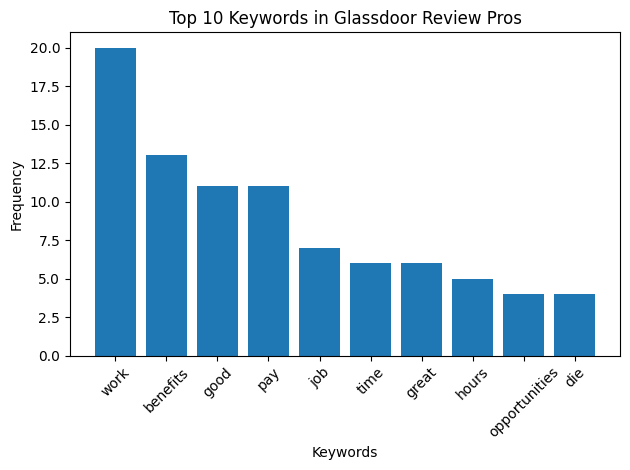

In [ ]:
import matplotlib.pyplot as plt

pros_most_common = pros_word_counts.most_common(10)
words, counts = zip(*pros_most_common)

plt.bar(words, counts)
plt.title("Top 10 Keywords in Glassdoor Review Pros")
plt.xlabel("Keywords")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
from nltk.util import ngrams

bigrams = list(ngrams(all_pros_words, 2))
trigrams = list(ngrams(all_pros_words, 3))

bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

In [ ]:
print(bigram_counts.most_common(3))

[(('pay', 'benefits'), 4), (('easy', 'work'), 3), (('good', 'pay'), 3)]


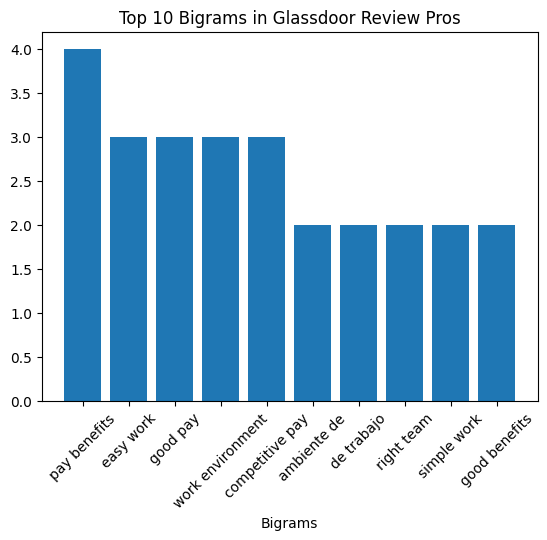

In [ ]:
common_bigrams = bigram_counts.most_common(10)
bg_labels = [' '.join(bg) for bg, count in common_bigrams]
bg_counts = [count for bg, count in common_bigrams]

plt.bar(bg_labels, bg_counts)
plt.title("Top 10 Bigrams in Glassdoor Review Pros")
plt.xlabel("Bigrams")
plt.xticks(rotation=45)
plt.show()

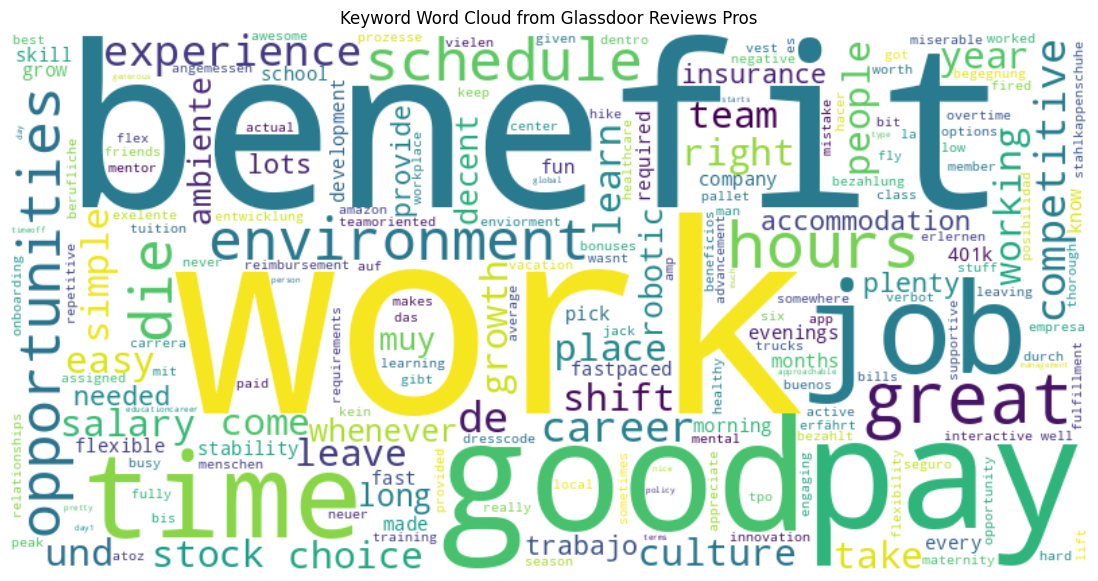

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_pros_words))

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Keyword Word Cloud from Glassdoor Reviews Pros")
plt.show()

In [ ]:
# Join all cleaned pros into one big string, then split into words
all_cons_words = ' '.join(glass['cleaned_cons']).split()

# Count frequency of each word
cons_word_counts = Counter(all_cons_words)

print(cons_word_counts.most_common(5))

[('work', 18), ('get', 14), ('’', 13), ('time', 9), ('environment', 7)]


In [ ]:
glass_cons_df = pd.DataFrame(cons_word_counts.items(), columns=['word', 'count']).sort_values(by='count', ascending=False)

print(glass_cons_df.head())

           word  count
45         work     18
10          get     14
265           ’     13
47         time      9
22   management      7


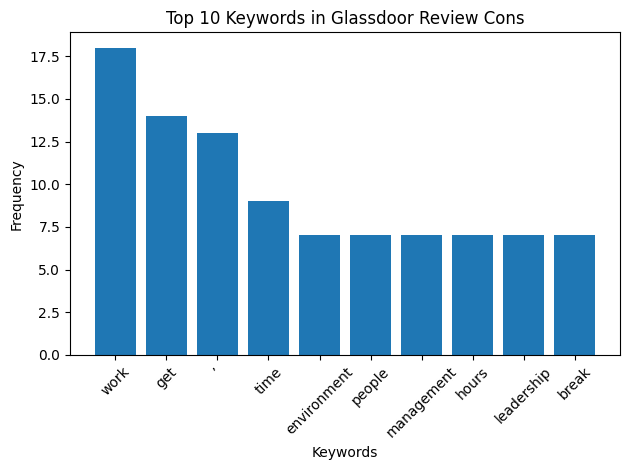

In [ ]:
cons_most_common = cons_word_counts.most_common(10)
words, counts = zip(*cons_most_common)

plt.bar(words, counts)
plt.title("Top 10 Keywords in Glassdoor Review Cons")
plt.xlabel("Keywords")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

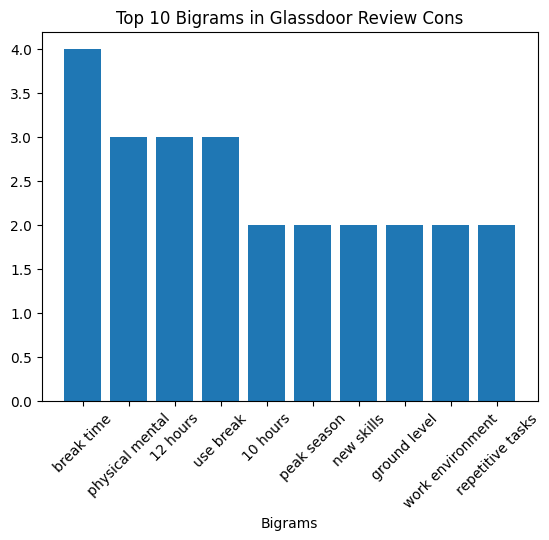

In [ ]:
bigrams = list(ngrams(all_cons_words, 2))
trigrams = list(ngrams(all_cons_words, 3))

bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

common_bigrams = bigram_counts.most_common(10)
bg_labels = [' '.join(bg) for bg, count in common_bigrams]
bg_counts = [count for bg, count in common_bigrams]

plt.bar(bg_labels, bg_counts)
plt.title("Top 10 Bigrams in Glassdoor Review Cons")
plt.xlabel("Bigrams")
plt.xticks(rotation=45)
plt.show()

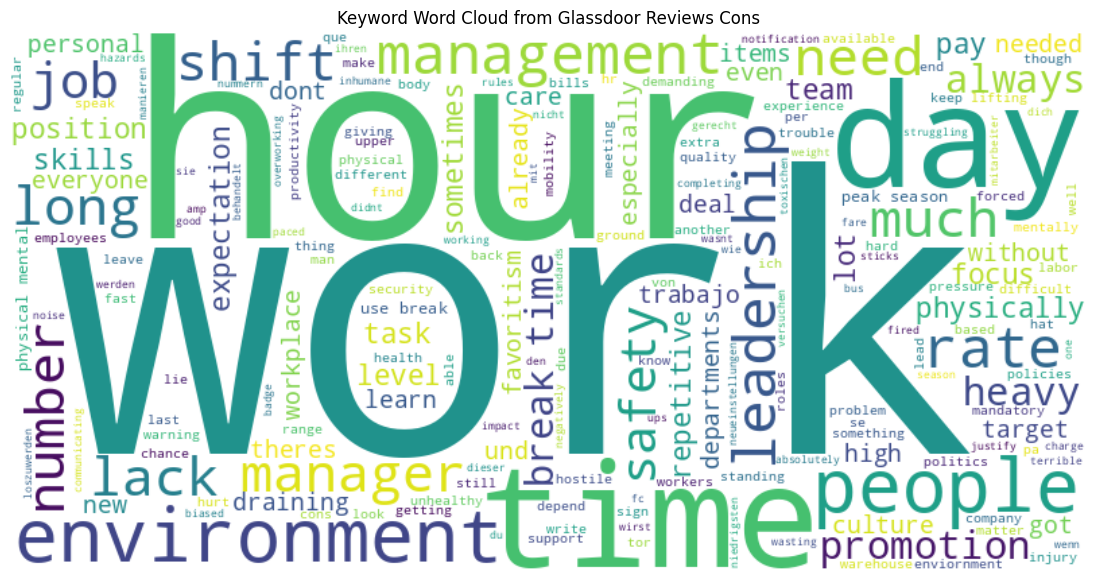

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_cons_words))

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Keyword Word Cloud from Glassdoor Reviews Cons")
plt.show()

### Youtube

In [ ]:
all_transcript_words = ' '.join(youtube['transcript_cleaned']).split()

transcript_word_counts = Counter(all_transcript_words)

In [ ]:
print(transcript_word_counts.most_common(5))

[('like', 498), ('um', 225), ('im', 218), ('get', 197), ('work', 155)]


In [ ]:
stop_transcript_keywords = ['music', 'thats', 'want', 'yeah', 'got', 'like','um', 'im', 'get', 'dont', 'go', 'youre', 'know', 'going', 'really', 'gon', 'na', 'guys', 'one']
filtered_words = [word for word in all_transcript_words if word not in stop_transcript_keywords]
filtered_counts = Counter(filtered_words)

In [ ]:
transcript_df = pd.DataFrame(filtered_counts.items(), columns=['word', 'count']).sort_values(by='count', ascending=False)
print(transcript_df.head())

       word  count
94     work    155
4      time    140
64      day    124
2    amazon    105
116  people     94


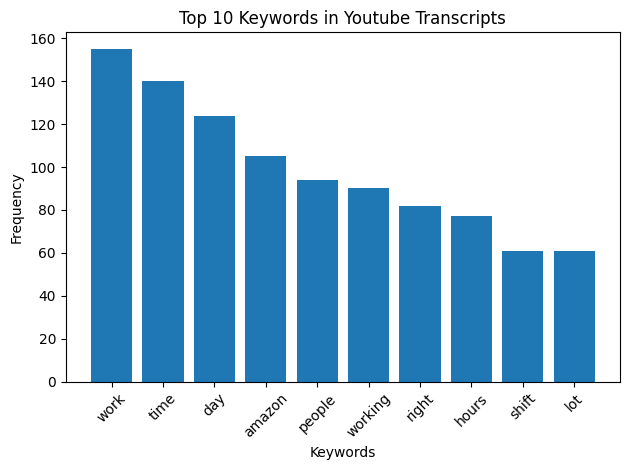

In [ ]:
transcript_most_common = filtered_counts.most_common(10)
words, counts = zip(*transcript_most_common)

plt.bar(words, counts)
plt.title("Top 10 Keywords in Youtube Transcripts")
plt.xlabel("Keywords")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
bigrams = list(ngrams(filtered_words, 2))
trigrams = list(ngrams(filtered_words, 3))

bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

In [ ]:
print(bigram_counts.most_common(3))

[(('working', 'amazon'), 34), (('make', 'sure'), 29), (('paid', 'time'), 13)]


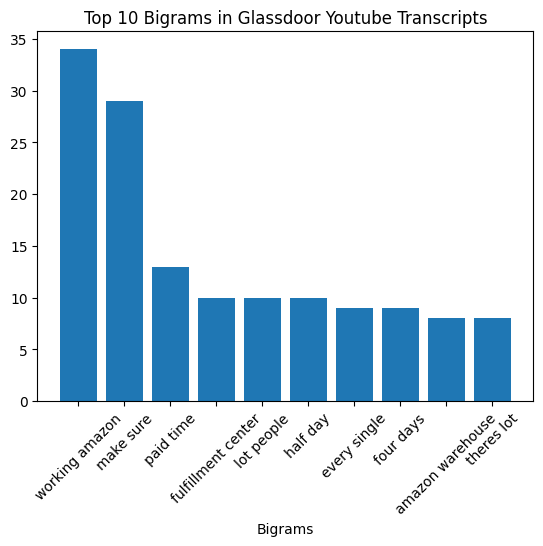

In [ ]:
common_bigrams = bigram_counts.most_common(10)
bg_labels = [' '.join(bg) for bg, count in common_bigrams]
bg_counts = [count for bg, count in common_bigrams]

plt.bar(bg_labels, bg_counts)
plt.title("Top 10 Bigrams in Glassdoor Youtube Transcripts")
plt.xlabel("Bigrams")
plt.xticks(rotation=45)
plt.show()

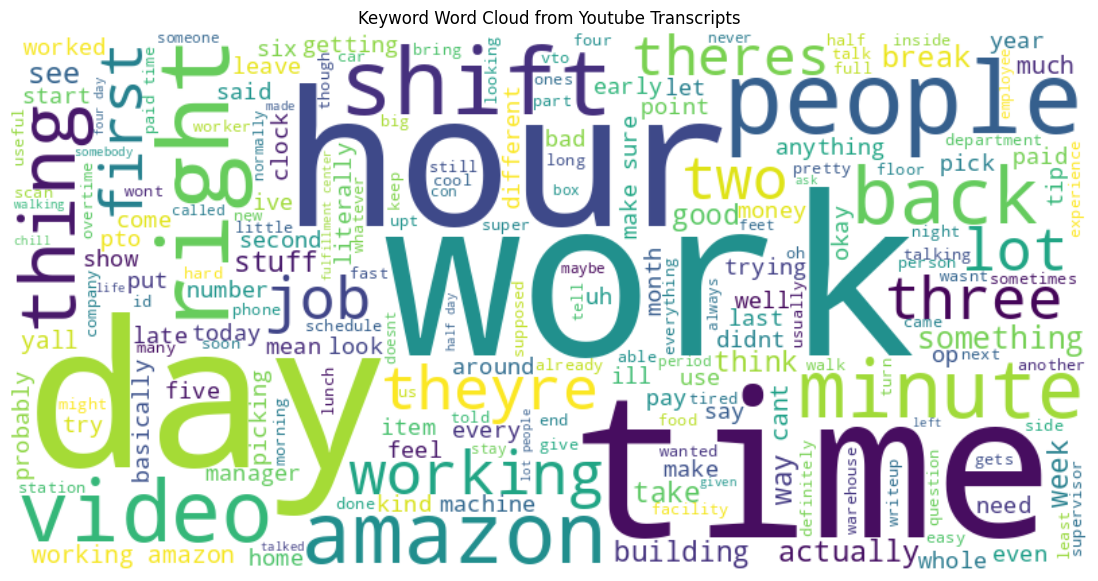

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(filtered_words))

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Keyword Word Cloud from Youtube Transcripts")
plt.show()

## Sentiment Analysis

### Glassdoor Sentiment

In [ ]:
from textblob import TextBlob
import matplotlib.pyplot as plt

In [ ]:
text_columns = [
    'cleaned_summary',
    'cleaned_advice',
    'cleaned_pros',
    'cleaned_cons'
]

glass['cleaned_text'] = (
    glass[text_columns]
    .fillna('')
    .agg(' '.join, axis=1)
)

In [ ]:
glass['cleaned_text'].head()

,cleaned_text
0,amazon ’ micro manage interactive leave take w...
1,good remove attitude manager warehouse good ea...
2,warehouse physical strength learn lift trucks ...
3,less ideal decent work wasnt miserable people...
4,amazon get better good pay long hours manageme...


In [ ]:
glass['sentiment_polarity'] = glass['cleaned_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
glass['sentiment_subjectivity'] = glass['cleaned_text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

In [ ]:
def label_sentiment(score):
    if score > 0.1:
        return 'positive'
    elif score < -0.1:
        return 'negative'
    else:
        return 'neutral'

glass['sentiment_label'] = glass['sentiment_polarity'].apply(label_sentiment)

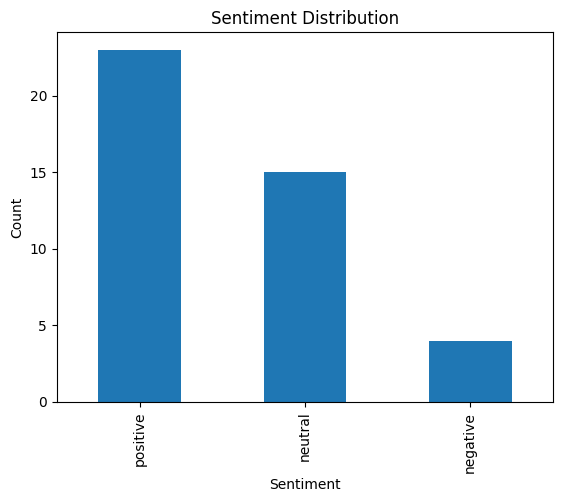

In [ ]:
glass['sentiment_label'].value_counts().plot(kind='bar', title="Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

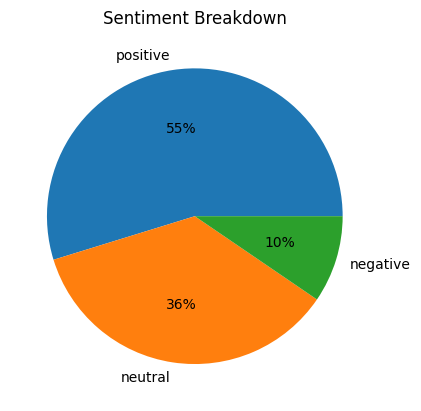

In [ ]:
glass['sentiment_label'].value_counts().plot(
    kind='pie',
    autopct='%1.0f%%',
    title="Sentiment Breakdown"
)
plt.ylabel('')
plt.show()

In [ ]:
glass.to_csv("glassdoor_sentiment.csv", index=False)

### Youtube Sentiment

In [ ]:
from textblob import TextBlob

youtube['sentiment_polarity'] = youtube['transcript_cleaned'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
youtube['sentiment_subjectivity'] = youtube['transcript_cleaned'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

In [ ]:
print(youtube.head())

   Video_Number                                         Link Upload_Date  \
0             1  https://www.youtube.com/watch?v=tgWkQC3_b30    May 2020   
1             2  https://www.youtube.com/watch?v=_kVao-XyKgQ    Jun 2020   
2             3  https://www.youtube.com/watch?v=3ytZ8_6ieoI   June 2021   
3             4  https://www.youtube.com/watch?v=jzg4snTtk3E    Aug 2022   
4             5  https://www.youtube.com/watch?v=kXOb9lfWU9w    Dec 2023   

     Views  Likes  Comments  \
0  1653124  23000      7974   
1   525522  24000      2395   
2   114049   2300       543   
3   227920   3500       753   
4     7346    298        41   

                                          Transcript  \
0  0:08\nwhat is up guys I'm back with another\n0...   
1  Intro\n0:00\nwhat is up guys I'm back with yet...   
2  0:00\nso today's video is going to be a little...   
3  0:00\n[Music]\n0:07\nso it's 7 23\n0:09\nmy sh...   
4  0:00\n[Music]\n0:06\nI hey you guys what's up ...   

                   

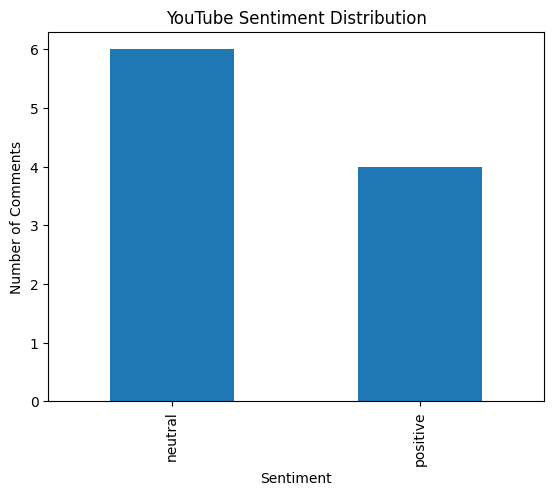

In [ ]:
youtube['sentiment_label'] = youtube['sentiment_polarity'].apply(label_sentiment)
youtube['sentiment_label'].value_counts().plot(kind='bar', title="YouTube Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()

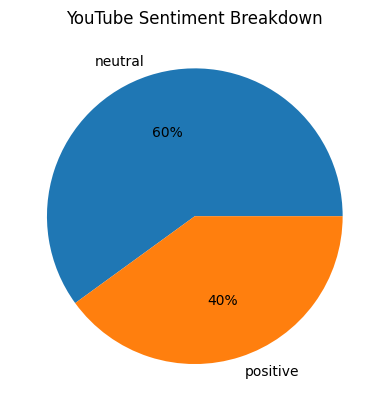

In [ ]:
youtube['sentiment_label'].value_counts().plot(
    kind='pie',
    autopct='%1.0f%%',
    title="YouTube Sentiment Breakdown"
)
plt.ylabel('')
plt.show()

In [ ]:
youtube.to_csv('youtube_sentiment.csv', index=False)

## Combining Youtube and Glassdoor

In [ ]:
glass.rename(columns={'cleaned_text': 'cleaned_text'}, inplace=True)
youtube.rename(columns={'transcript_cleaned': 'cleaned_text'}, inplace=True)

In [ ]:
glass['platform'] = 'Glassdoor'
youtube['platform'] = 'YouTube'

In [ ]:
combined_df = pd.concat([glass, youtube], ignore_index=True)

In [ ]:
combined_df.head()

,review_id,rating_date,count_helpful,count_unhelpful,employee_length,employee_status,employee_type,flags_business_outlook,flags_ceo_approval,flags_recommend_frend,...,sentiment_subjectivity,sentiment_label,platform,Video_Number,Link,Upload_Date,Views,Likes,Comments,Transcript
0,1.0,2025-06-03T00:00:00.000Z,0.0,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,...,0.495238,negative,Glassdoor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,2025-05-29T00:00:00.000Z,0.0,0.0,1.0,CONTRACT,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,...,0.677778,positive,Glassdoor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.0,2025-05-17T00:00:00.000Z,0.0,0.0,4.0,REGULAR,Current employees,NEGATIVE,NO_OPINION,NEGATIVE,...,0.371429,neutral,Glassdoor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8.0,2025-05-15T00:00:00.000Z,0.0,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,...,0.666667,positive,Glassdoor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9.0,2025-05-14T00:00:00.000Z,0.0,0.0,1.0,REGULAR,"Former employee, less than 1 year",NaN,NaN,NaN,...,0.625000,neutral,Glassdoor,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
combined_df.to_csv('combined_sentiment_data.csv', index=False)

## Themes

In [ ]:
def tag_themes(text, theme_keywords):
    matched_themes = []
    for theme, keywords in theme_keywords.items():
        if any(keyword in str(text).lower() for keyword in keywords):
            matched_themes.append(theme)
    return ', '.join(matched_themes) if matched_themes else ''

In [ ]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   review_id                     42 non-null     float64
 1   rating_date                   42 non-null     object 
 2   count_helpful                 42 non-null     float64
 3   count_unhelpful               42 non-null     float64
 4   employee_length               42 non-null     float64
 5   employee_status               42 non-null     object 
 6   employee_type                 42 non-null     object 
 7   flags_business_outlook        28 non-null     object 
 8   flags_ceo_approval            29 non-null     object 
 9   flags_recommend_frend         32 non-null     object 
 10  rating_culture_values         42 non-null     float64
 11  rating_diversity_inclusion    42 non-null     float64
 12  rating_overall                42 non-null     float64
 13  rating_

In [ ]:
theme_keywords = {
    'Burnout': ['tired','exhausted','overworked','burnout','burned out',
    'stress','stressful','no break','breaks','long shift',
    'physically demanding','body hurts','sore','fatigue'],

    'Training Gaps': ['training','onboarding','no support','confused',
    'no guidance','lack of training','unclear'],

    'Management Issues': ['manager','management','supervisor','leadership',
    'bad management','poor management','micromanage',
    'micromanagement','favoritism','unfair'],

    'Scheduling Issues': ['shift','hours','schedule','night shift','weekend',
    'overtime','mandatory overtime','met','long hours'],

    'Performance Pressure': ['rate','quota','metrics','performance','productivity',
    'fast pace','pressure','numbers'],

    'Pay Issues': ['pay','salary','wage','low pay','underpaid',
    'raises','bonus','benefits'],

'Safety Concerns': ['safety','unsafe','injury','dangerous','accident']
}

combined_df['Theme'] = combined_df['cleaned_text'].apply(lambda x: tag_themes(x, theme_keywords))

In [ ]:
print(combined_df.head())

   review_id               rating_date  count_helpful  count_unhelpful  \
0        1.0  2025-06-03T00:00:00.000Z            0.0              0.0   
1        2.0  2025-05-29T00:00:00.000Z            0.0              0.0   
2        7.0  2025-05-17T00:00:00.000Z            0.0              0.0   
3        8.0  2025-05-15T00:00:00.000Z            0.0              0.0   
4        9.0  2025-05-14T00:00:00.000Z            0.0              0.0   

   employee_length employee_status                       employee_type  \
0              0.0         REGULAR                    Current employee   
1              1.0        CONTRACT  Current employee, less than 1 year   
2              4.0         REGULAR                   Current employees   
3              0.0         REGULAR                    Current employee   
4              1.0         REGULAR   Former employee, less than 1 year   

  flags_business_outlook flags_ceo_approval flags_recommend_frend  ...  \
0                    NaN            

In [ ]:
combined_df.to_csv('combined_with_themes.csv', index=False)

In [ ]:
combined_df['employee_status'].value_counts()

,count
employee_status,
REGULAR,37
CONTRACT,3
PART_TIME,2


In [ ]:
combined_df['employee_job_title'].value_counts()

,count
employee_job_title,
Warehouse Associate,6
Associate,5
Picker/Packer,3
FC Associate I,3
Warehouse Fulfillment Associate,2
Process Associate,2
Inbound Stower,2
ICQA Associate,2
Driver,1


In [ ]:
combined_df['Segment'] = 'Other'

In [ ]:
combined_df.head()

,review_id,rating_date,count_helpful,count_unhelpful,employee_length,employee_status,employee_type,flags_business_outlook,flags_ceo_approval,flags_recommend_frend,...,platform,Video_Number,Link,Upload_Date,Views,Likes,Comments,Transcript,Theme,Segment
0,1.0,2025-06-03T00:00:00.000Z,0.0,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,...,Glassdoor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,Other
1,2.0,2025-05-29T00:00:00.000Z,0.0,0.0,1.0,CONTRACT,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,...,Glassdoor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Management Issues,Other
2,7.0,2025-05-17T00:00:00.000Z,0.0,0.0,4.0,REGULAR,Current employees,NEGATIVE,NO_OPINION,NEGATIVE,...,Glassdoor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Scheduling Issues, Performance Pressure",Other
3,8.0,2025-05-15T00:00:00.000Z,0.0,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,...,Glassdoor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,Other
4,9.0,2025-05-14T00:00:00.000Z,0.0,0.0,1.0,REGULAR,"Former employee, less than 1 year",NaN,NaN,NaN,...,Glassdoor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Management Issues, Scheduling Issues, Pay Issues",Other


In [ ]:
combined_df.loc[
    combined_df['employee_job_title'].isin([
        'Warehouse Associate',
        'Associate',
        'FC Associate I',
        'Warehouse Fulfillment Associate',
        'Fulfillment Associate',
        'Fulfillment Center Warehouse Associate',
        'AA(Amazon Associate)',
        'Mozo De Almacen'
    ]),
    'Segment'
] = 'Warehouse Associates'

In [ ]:
combined_df.loc[
    combined_df['employee_job_title'].isin([
        'Picker/Packer',
        'Order Picker',
        'Cherry Picker',
        'Inbound Stower',
        'Inbound Receive Dock',
        'Palletizer'
    ]),
    'Segment'
] = 'Picking / Stowing Roles'

In [ ]:
combined_df.loc[
    combined_df['employee_job_title'].isin([
        'Process Associate',
        'ICQA Associate'
    ]),
    'Segment'
] = 'Process / Inventory Roles'

In [ ]:
combined_df.loc[
    combined_df['employee_job_title'].isin([
        'Driver',
        'Driver Associate'
    ]),
    'Segment'
] = 'Drivers'

In [ ]:
combined_df.loc[
    combined_df['employee_job_title'].isin([
        'Area Manager',
        'Operations Manager',
        'Sr Program Manager',
        'IT Support Engineer',
        'Data Analyst'
    ]),
    'Segment'
] = 'Management / Professional'

In [ ]:
combined_df['Segment'].value_counts()

,count
Segment,
Warehouse Associates,20
Other,12
Picking / Stowing Roles,9
Management / Professional,5
Process / Inventory Roles,4
Drivers,2


In [ ]:
combined_df.to_csv('combined_with_themes_v2.csv', index=False)

In [ ]:
combined_df['theme_list'] = combined_df['Theme'].str.split(', ')

In [ ]:
combined_df.head()

,review_id,rating_date,count_helpful,count_unhelpful,employee_length,employee_status,employee_type,flags_business_outlook,flags_ceo_approval,flags_recommend_frend,...,Video_Number,Link,Upload_Date,Views,Likes,Comments,Transcript,Theme,Segment,theme_list
0,1.0,2025-06-03T00:00:00.000Z,0.0,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,Warehouse Associates,[]
1,2.0,2025-05-29T00:00:00.000Z,0.0,0.0,1.0,CONTRACT,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Management Issues,Warehouse Associates,[Management Issues]
2,7.0,2025-05-17T00:00:00.000Z,0.0,0.0,4.0,REGULAR,Current employees,NEGATIVE,NO_OPINION,NEGATIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Scheduling Issues, Performance Pressure",Warehouse Associates,"[Scheduling Issues, Performance Pressure]"
3,8.0,2025-05-15T00:00:00.000Z,0.0,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,Other,[]
4,9.0,2025-05-14T00:00:00.000Z,0.0,0.0,1.0,REGULAR,"Former employee, less than 1 year",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Management Issues, Scheduling Issues, Pay Issues",Warehouse Associates,"[Management Issues, Scheduling Issues, Pay Iss..."


In [ ]:
themes_exploded = combined_df.explode('theme_list')

In [ ]:
themes_exploded['theme_list'].value_counts()

,count
theme_list,
Pay Issues,33
Scheduling Issues,32
Management Issues,27
Performance Pressure,20
Burnout,14
Safety Concerns,10
Training Gaps,9
,5


In [ ]:
themes_exploded.head()

,review_id,rating_date,count_helpful,count_unhelpful,employee_length,employee_status,employee_type,flags_business_outlook,flags_ceo_approval,flags_recommend_frend,...,Video_Number,Link,Upload_Date,Views,Likes,Comments,Transcript,Theme,Segment,theme_list
0,1.0,2025-06-03T00:00:00.000Z,0.0,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,Warehouse Associates,
1,2.0,2025-05-29T00:00:00.000Z,0.0,0.0,1.0,CONTRACT,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Management Issues,Warehouse Associates,Management Issues
2,7.0,2025-05-17T00:00:00.000Z,0.0,0.0,4.0,REGULAR,Current employees,NEGATIVE,NO_OPINION,NEGATIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Scheduling Issues, Performance Pressure",Warehouse Associates,Scheduling Issues
2,7.0,2025-05-17T00:00:00.000Z,0.0,0.0,4.0,REGULAR,Current employees,NEGATIVE,NO_OPINION,NEGATIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Scheduling Issues, Performance Pressure",Warehouse Associates,Performance Pressure
3,8.0,2025-05-15T00:00:00.000Z,0.0,0.0,0.0,REGULAR,Current employee,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,Other,


In [ ]:
theme_counts = (themes_exploded.groupby(['Segment', 'theme_list']).size().reset_index(name='count'))

In [ ]:
theme_table = theme_counts.pivot(index='Segment', columns='theme_list', values='count').fillna(0)

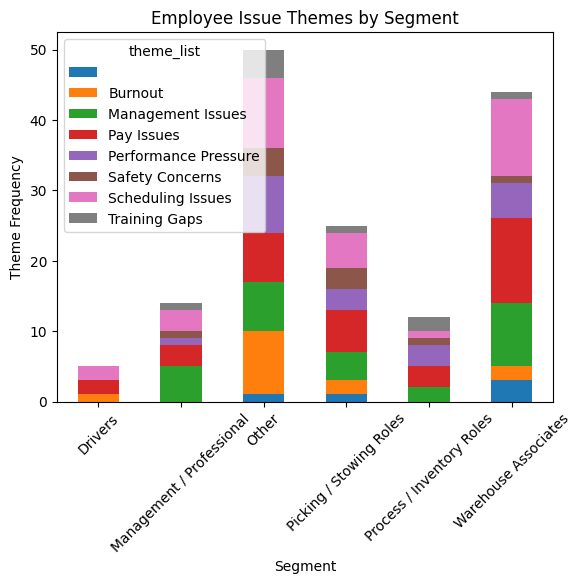

In [ ]:
theme_table.plot(kind='bar', stacked=True)
plt.ylabel("Theme Frequency")
plt.title("Employee Issue Themes by Segment")
plt.xticks(rotation=45)
plt.show()

In [ ]:
theme_frequency = pd.crosstab(
    themes_exploded['Segment'],
    themes_exploded['theme_list'])

In [ ]:
theme_frequency.head()

theme_list,,Burnout,Management Issues,Pay Issues,Performance Pressure,Safety Concerns,Scheduling Issues,Training Gaps
Segment,,,,,,,,
Drivers,0,1,0,2,0,0,2,0
Management / Professional,0,0,5,3,1,1,3,1
Other,1,9,7,7,8,4,10,4
Picking / Stowing Roles,1,2,4,6,3,3,5,1
Process / Inventory Roles,0,0,2,3,3,1,1,2


In [ ]:
theme_frequency.to_csv('theme_frequency.csv')

In [ ]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   review_id                     42 non-null     float64
 1   rating_date                   42 non-null     object 
 2   count_helpful                 42 non-null     float64
 3   count_unhelpful               42 non-null     float64
 4   employee_length               42 non-null     float64
 5   employee_status               42 non-null     object 
 6   employee_type                 42 non-null     object 
 7   flags_business_outlook        28 non-null     object 
 8   flags_ceo_approval            29 non-null     object 
 9   flags_recommend_frend         32 non-null     object 
 10  rating_culture_values         42 non-null     float64
 11  rating_diversity_inclusion    42 non-null     float64
 12  rating_overall                42 non-null     float64
 13  rating_

In [ ]:
wa_pressure = combined_df[
    (combined_df['Segment'] == 'Warehouse Associates') &
    (combined_df['theme_list'].apply(lambda x: 'Performance Pressure' in x))
]

In [ ]:
len(wa_pressure)

5

In [ ]:
text = " ".join(wa_pressure['cleaned_text'])

In [ ]:
from collections import Counter

word_counts = Counter(text.split())

common_words = word_counts.most_common(20)
common_words

[('associates', 7),
 ('managers', 6),
 ('work', 6),
 ('rate', 5),
 ('learn', 4),
 ('safety', 4),
 ('level', 4),
 ('get', 4),
 ('people', 4),
 ('environment', 3),
 ('everyone', 3),
 ('chance', 3),
 ('bcz', 3),
 ('hr', 3),
 ('needs', 3),
 ('ground', 3),
 ('productivity', 3),
 ('got', 3),
 ('new', 3),
 ('skills', 3)]

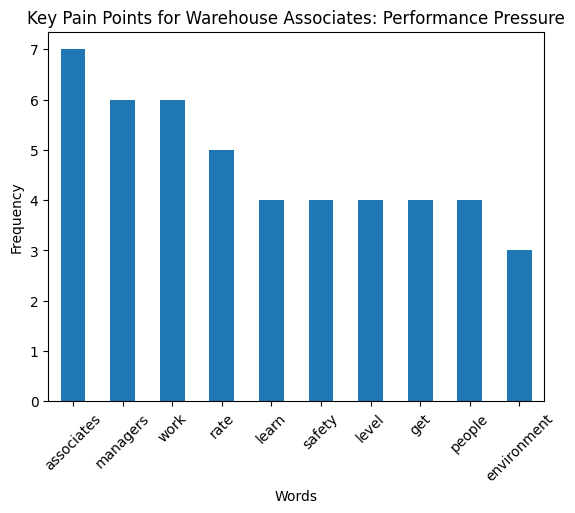

In [ ]:
pain_points.head(10).plot(
    kind='bar',
    x='word',
    y='count',
    legend=False
)

plt.title("Key Pain Points for Warehouse Associates: Performance Pressure")
plt.ylabel("Frequency")
plt.xlabel("Words")
plt.xticks(rotation=45)
plt.show()

In [ ]:
pain_points = pd.DataFrame(common_words, columns=['word', 'count'])
pain_points

,word,count
0,associates,7
1,managers,6
2,work,6
3,rate,5
4,learn,4
5,safety,4
6,level,4
7,get,4
8,people,4
9,environment,3


In [ ]:
wa_pressure['quote'] = (
    wa_pressure['summary'] + " " +
    wa_pressure['review_cons'] + " " +
    wa_pressure['advice_to_management']
)

quotes = wa_pressure[['Segment', 'quote']]
quotes

/tmp/ipykernel_303/626659967.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wa_pressure['quote'] = (


,Segment,quote
2,Warehouse Associates,"warehouse fast paced working environment, weig..."
11,Warehouse Associates,"Review of Fulfillment Centre at St. Thomas, ON..."
28,Warehouse Associates,MCO1 Stow very physically demanding\nkeeping y...
33,Warehouse Associates,Not Bad Their rate per hour is slightly unreas...
36,Warehouse Associates,Review Poor management support.\nLack of under...


In [ ]:
print(quotes)

                 Segment                                              quote
2   Warehouse Associates  warehouse fast paced working environment, weig...
11  Warehouse Associates  Review of Fulfillment Centre at St. Thomas, ON...
28  Warehouse Associates  MCO1 Stow very physically demanding\nkeeping y...
33  Warehouse Associates  Not Bad Their rate per hour is slightly unreas...
36  Warehouse Associates  Review Poor management support.\nLack of under...
